# Worksheet 10

## - 23MS121 
## - Manish Behera

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Q1

In [5]:
def generate_random_integer(min_val, max_val):
   
    if min_val > max_val:
        min_val, max_val = max_val, min_val
    
    # np.random.rand() generates a float in [0.0, 1.0)
    # We scale it to the range of integers we want.
    random_int = np.floor(np.random.rand() * (max_val - min_val + 1) + min_val)
    return int(random_int)

In [9]:
n1 = int(input("Enter the n1: "))
n2 = int(input("Enter the n2: "))

random_number = generate_random_integer(n1, n2)
print(f"A random integer between {n1} and {n2} is: {random_number}")

A random integer between 55 and 77 is: 74


### Q2

In [12]:

num_simulations = 100000  
meet_count = 0

for _ in range(num_simulations):
    tA = 30 * np.random.random()
    tB = 30 * np.random.random()
    
    meet = False
    if tA < tB:
        if tB - tA < 5:
            meet = True
    else:  # tB <= tA
        if tA - tB < 10:
            meet = True
            
    if meet:
        meet_count += 1

probability = meet_count / num_simulations

print(f"Estimated probability of meeting is: {probability}")


Estimated probability of meeting is: 0.43027


### Q3


In [16]:
def buffons_needle_simulation(l, d, num_trials=100000):
    
    crossings = 0
    for _ in range(num_trials):
        # i missied the class, so i'm using this logic to define intersection with the boundary line
        # generate a random distance from the center of the needle to the nearest line (y) and a random angle (theta)
        y = np.random.uniform(0, d / 2)
        theta = np.random.uniform(0, np.pi / 2)
        
        # Condition for the needle to cross a line
        if y <= (l / 2) * np.sin(theta):
            crossings += 1
            
    return crossings / num_trials

l1 = 4.0 
d1 = 5.0  
print(f"C1, Needle length l = {l1}, Strip width d = {d1} (l < d)")
prob_case1 = buffons_needle_simulation(l1, d1)
print(f"Estimated Probability: {prob_case1:.5f}")

l2 = 6.0  
d2 = 5.0  
print(f"C2, Needle length l = {l2}, Strip width d = {d2} (l >= d)")
prob_case2 = buffons_needle_simulation(l2, d2)
print(f"Estimated Probability: {prob_case2:.5f}")

C1, Needle length l = 4.0, Strip width d = 5.0 (l < d)
Estimated Probability: 0.51079
C2, Needle length l = 6.0, Strip width d = 5.0 (l >= d)
Estimated Probability: 0.71312


### Q4

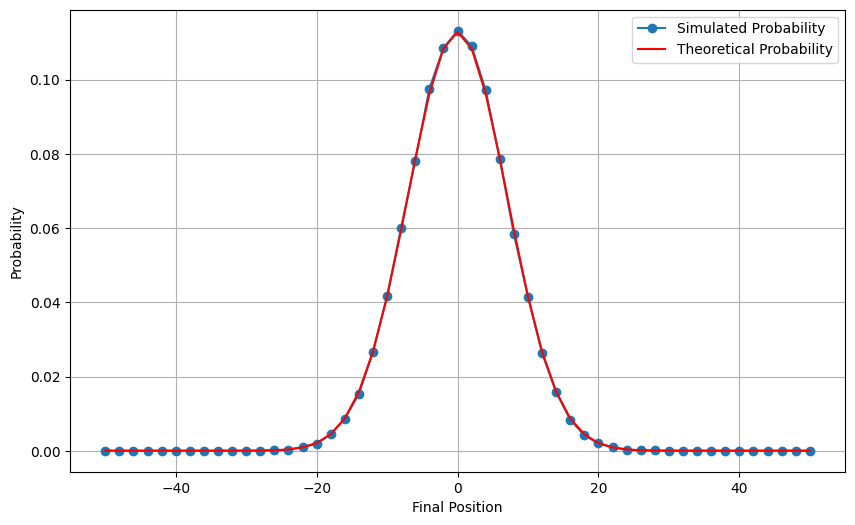

In [20]:
def take_a_step():
    s = np.random.rand()
    if s > 0.5:
        return 1
    else:
        return -1

def random_walk(steps):
    pos = 0
    for _ in range(steps):
        pos += take_a_step()
    return pos

num_walkers = 100000
num_steps = 50

final_positions = np.zeros(num_steps + 1)
for _ in range(num_walkers):
    final_pos = random_walk(num_steps)
    pos_in_array = int((final_pos + num_steps) / 2)
    final_positions[pos_in_array] += 1

positions = np.linspace(-num_steps, num_steps, num_steps + 1)

# Normalize to get probability
prob_simulated = final_positions / num_walkers

def prob_theoretical(n, N):
    return (2 / np.sqrt(2 * np.pi * N)) * np.exp(-n**2 / (2 * N))

prob_exact = prob_theoretical(positions, num_steps)

plt.figure(figsize=(10, 6))
plt.plot(positions, prob_simulated, 'o-', label='Simulated Probability')
plt.plot(positions, prob_exact, 'r-', label='Theoretical Probability')
plt.xlabel('Final Position')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()


### Q4

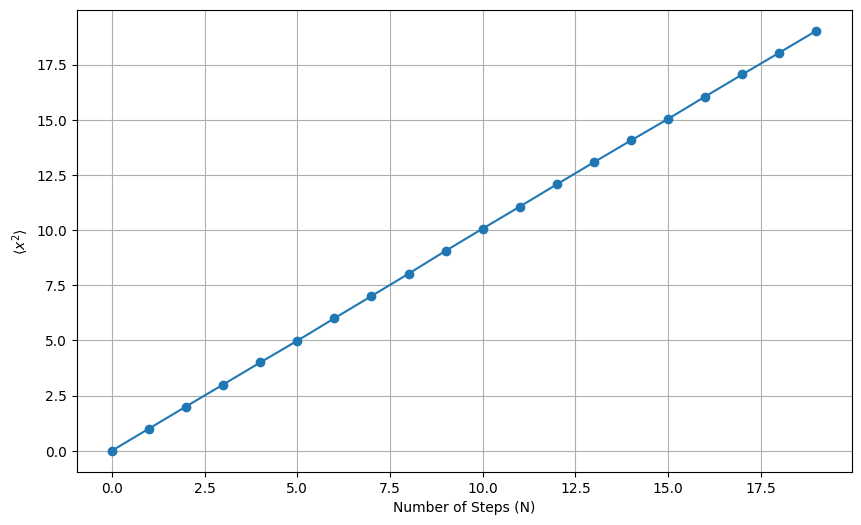

In [23]:
num_walkers = 100000
num_steps = 20

positions = np.zeros(num_walkers, dtype=int)
xaverage_sq = np.zeros(num_steps)

for step in range(num_steps):
    xaverage_sq[step] = np.mean(positions**2)
    for walker in range(num_walkers):
        positions[walker] += take_a_step()
    
steps = np.arange(num_steps)

plt.figure(figsize=(10, 6))
plt.plot(steps, xaverage_sq, 'o-')
plt.xlabel('Number of Steps (N)')
plt.ylabel(r'$\langle x^2 \rangle$')
plt.grid(True)
plt.show()